In [1]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D

from qutip import *
import numpy as np

from tomo_plot_hammer import *
from tomo_plot_3d import *
from ipywidgets import interact, IntSlider

In [2]:
spin_dim = 7/2
Ix = jmat(spin_dim,'x')
Iy = jmat(spin_dim,'y')
Iz = jmat(spin_dim,'z')
Ix_square = Ix * Ix
Iz_square = Iz * Iz
Ip = jmat(spin_dim, '+')
Im = jmat(spin_dim, '-')

def Hz_order(gamma, order):
    H = gamma * Iz **(order) / (order * (7/2) ** (order -1 ))
    return H


In [3]:
# Hilbert space dimension
d = 8

# non-linear strength in radians
gamma = 2*np.pi*400
Hzz = Hz_order(gamma, 8)

# su(2) drivign strength
rabi_strength = 2*np.pi*1/(2*(1888409/1e9))

Hy = rabi_strength * -Iy

H_drive = Hy + Hzz


t_max = 3e-3

trotter_num_max = 20

tau = t_max/trotter_num_max

# Precompute single-step unitary for this dt (time-independent Trotter-1)
Uy  = (-1j * tau * Qobj(Hy)).expm()
Uzz = (-1j * tau * Qobj(Hzz)).expm()
U   = Uzz * Uy

# Floquet Analysis

In [4]:
T_period = None 
# Eigen-decomposition of the unitary U
eigvals, eigvecs = U.eigenstates()

# Numerical hygiene: project slight radius errors back to unit circle for display
eigvals = np.array(eigvals, dtype=complex)
magnitudes = np.abs(eigvals)
eigvals_display = eigvals / np.where(magnitudes==0, 1.0, magnitudes)

# Phases in [0, 2π) for a clean ascending order (use np.angle(eigvals) for (-π, π])
phases = np.mod(np.angle(eigvals), 2*np.pi)
order = np.argsort(phases)

eigvals_sorted = eigvals_display[order]
eigvecs_sorted = [eigvecs[i] for i in order]
phases_sorted = phases[order]

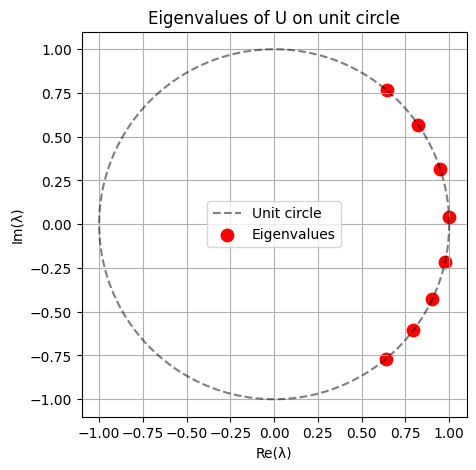

In [5]:
# Unit circle for reference
theta = np.linspace(0, 2*np.pi, 400)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

# Plot
plt.figure(figsize=(5,5))
plt.plot(circle_x, circle_y, 'k--', alpha=0.5, label='Unit circle')  # unit circle
plt.scatter(np.array(eigvals_sorted).real, np.array(eigvals_sorted).imag, color='red', s=80, label='Eigenvalues')

plt.gca().set_aspect('equal')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalues of U on unit circle")
plt.legend()
plt.grid(True)
plt.show()

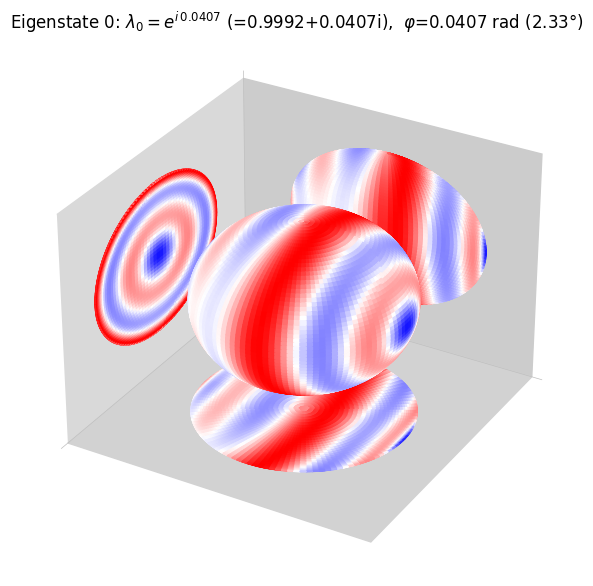

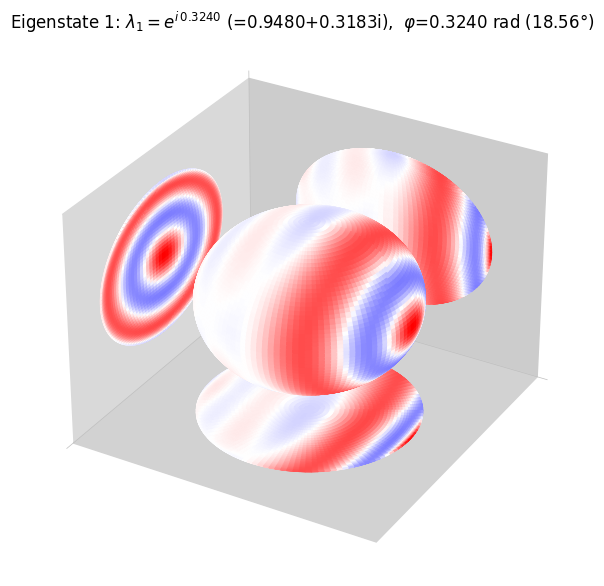

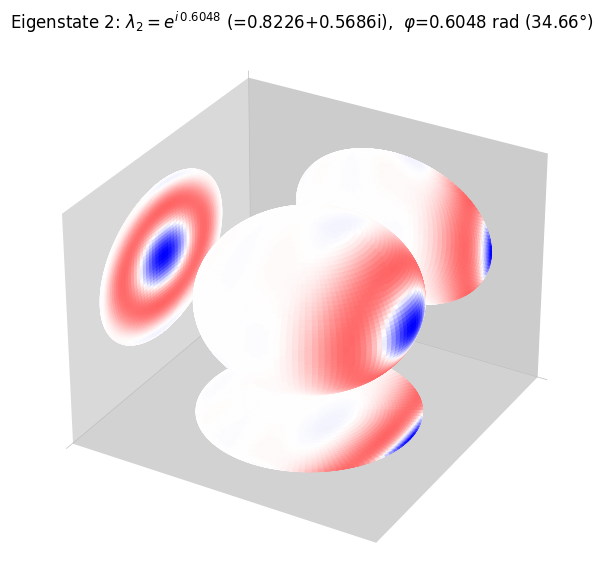

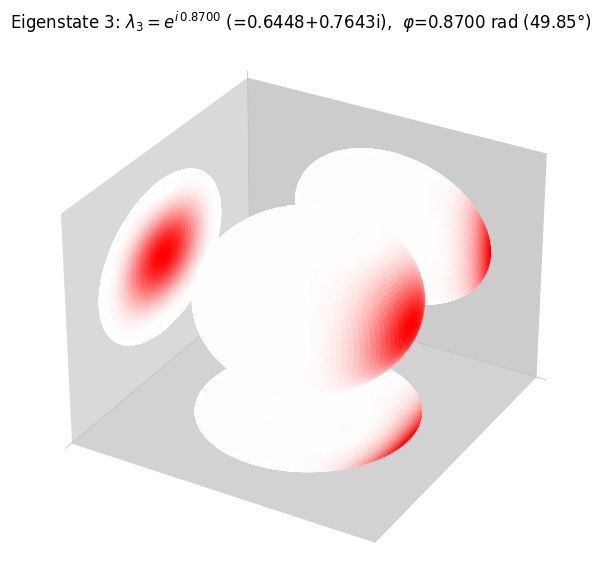

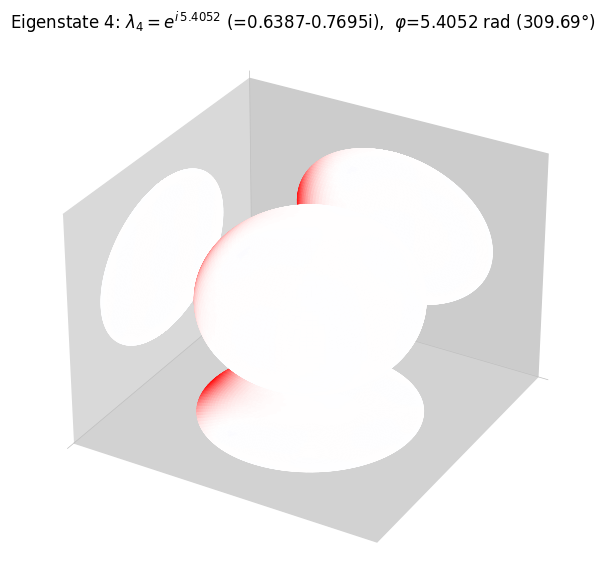

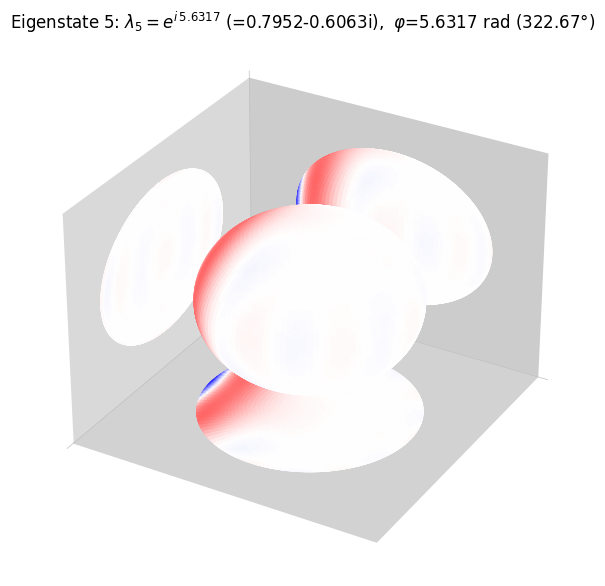

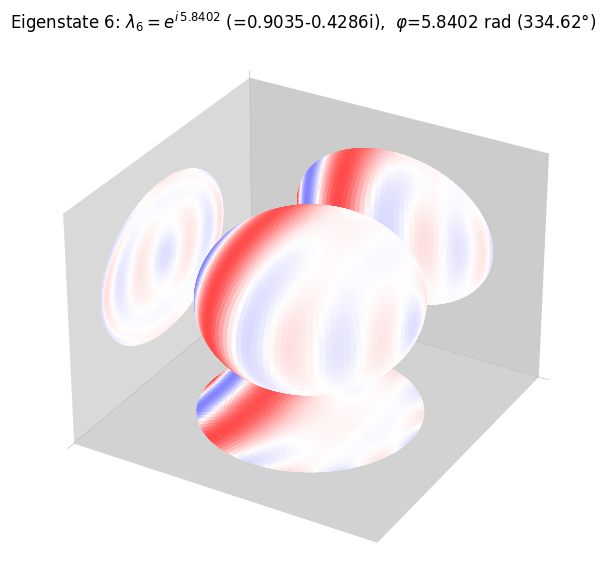

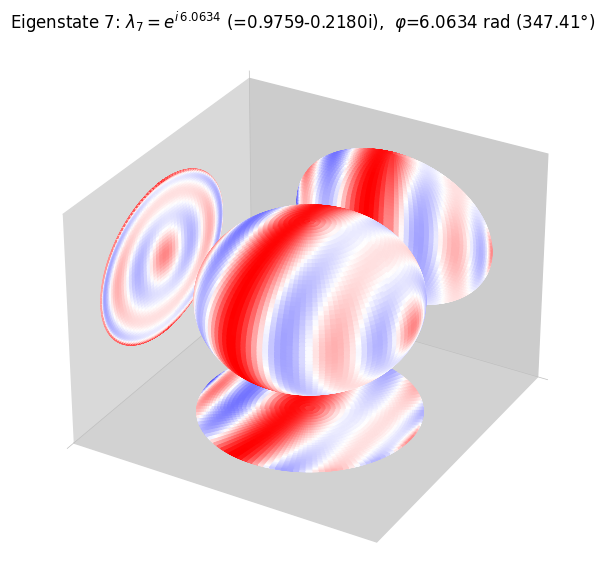

In [6]:
# Plot each eigenstate’s Wigner and label with its eigenvalue phase
for i, (lam, vec, phi) in enumerate(zip(eigvals_sorted, eigvecs_sorted, phases_sorted)):
    # Make a nice label: λ = e^{i φ}, show φ in rad and deg
    phi_deg = np.degrees(phi)
    lam_str = rf"$\lambda_{i} = e^{{i\,{phi:.4f}}}$ (={lam.real:.4f}{lam.imag:+.4f}i)"
    if T_period is not None:
        eps = phi / T_period  # quasienergy
        title = rf"Eigenstate {i}: {lam_str},  $\varphi$={phi:.4f} rad ({phi_deg:.2f}°),  $\epsilon$={eps:.4f}"
    else:
        title = rf"Eigenstate {i}: {lam_str},  $\varphi$={phi:.4f} rad ({phi_deg:.2f}°)"

    # Try to pass title into your plotting function; otherwise set via matplotlib
    try:
        tomo_plot_3d(vec, "wigner", title=title)  # if your function supports a 'title' kwarg
    except TypeError:
        tomo_plot_3d(vec, "wigner")
        plt.title(title)
        plt.gcf().canvas.draw_idle()

# Poincare Section

In [7]:
# ---------- Quantum-side helper (consistent scaling) ----------
def Hz_order(kappa, order, Iz, j):
    """
    Quantum nonlinearity Hzz = kappa * Iz**order / (order * j**(order-1))
    so that in the classical limit the twist angle is k * z**(order-1).
    """
    if order < 1 or int(order) != order:
        raise ValueError("order must be a positive integer")
    return (kappa / (order * (j**(order-1)))) * (Iz ** order)

# ---------- Small SO(3) helpers ----------
def rotate_x(v, angle):
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = v[...,0], v[...,1], v[...,2]
    x2 =  x
    y2 =  c*y - s*z
    z2 =  s*y + c*z
    out = np.stack([x2, y2, z2], axis=-1)
    return out / np.linalg.norm(out, axis=-1, keepdims=True)

def rotate_y(v, angle):
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = v[...,0], v[...,1], v[...,2]
    x2 =  c*x + s*z
    y2 =  y
    z2 = -s*x + c*z
    out = np.stack([x2, y2, z2], axis=-1)
    # keep on the unit sphere numerically
    return out / np.linalg.norm(out, axis=-1, keepdims=True)

def rotate_z(v, angle):
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = v[...,0], v[...,1], v[...,2]
    x2 =  c*x - s*y
    y2 =  s*x + c*y
    z2 =  z
    out = np.stack([x2, y2, z2], axis=-1)
    return out / np.linalg.norm(out, axis=-1, keepdims=True)

# ---------- Generalized kicked-top map ----------
def kicked_top_step_general(v, kappa, alpha, p_order):
    # twist about z by angle = kappa * sgn(z)*|z|^(p-1), then rotate about y by alpha
    if p_order < 1 or int(p_order) != p_order:
        raise ValueError("p_order must be a positive integer")
    z = v[..., 2]
    angle = kappa * np.sign(z) * (np.abs(z) ** (p_order - 1))  # <-- fix
    v1 = rotate_z(v, -angle)
    v2 = rotate_y(v1, -alpha) #-y rotation
    # v2 = rotate_y(v1, -alpha) #y rotation
    # v2 = rotate_x(v1, -alpha) #x rotation
    return v2

def spherical_angles(v):
    x, y, z = v[...,0], v[...,1], v[...,2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return phi, theta

def sph_to_cart(theta, phi):
    return np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])


def generate_trajectory(initial_v, kappa, alpha, p_order, N):
    traj = [initial_v]
    v = initial_v.copy()
    for _ in range(N):
        v = kicked_top_step_general(v, kappa, alpha, p_order)
        traj.append(v.copy())
    return np.array(traj)


def poincare_section_general(k, p=np.pi/2, order=2,
                             n_seeds_phi=12, n_seeds_theta=12,
                             n_iter=1500, n_discard=100):
    """
    Generate a Poincaré section (phi, theta) for the generalized kicked top.
    """
    phis = np.linspace(-np.pi, np.pi, n_seeds_phi, endpoint=False)
    thetas = np.linspace(0.15*np.pi, 0.85*np.pi, n_seeds_theta)


    # phis = [-0.289]
    # thetas = [1.174]

    seeds = []
    for th in thetas:
        for ph in phis:
            seeds.append(np.array([np.cos(ph)*np.sin(th),
                                   np.sin(ph)*np.sin(th),
                                   np.cos(th)]))
    v = np.stack(seeds, axis=0)

    pts_phi, pts_theta = [], []
    for i in range(n_iter):
        # loop explicitly over all seeds
        v = np.array([kicked_top_step_general(vi, k, p, order) for vi in v])
        if i >= n_discard:
            for vi in v:
                ph, th = spherical_angles(vi)   # single vector
                pts_phi.append(ph)
                pts_theta.append(th)

    return np.array(pts_phi), np.array(pts_theta)


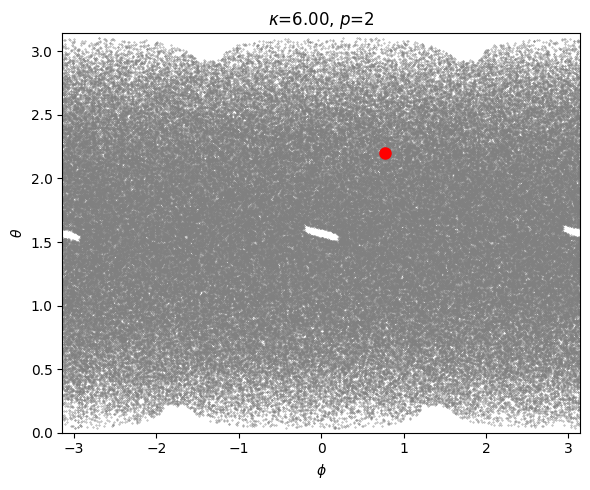

In [8]:
# ---------- Demo: reproduce your loop but with 'order' ----------
alpha = np.pi/2           # rotation about y per kick
k_list = [6]
order = 2               # p in your formula

for kappa in k_list:
    ph, th = poincare_section_general(kappa, alpha, order)  # use the fixed step above
    plt.figure(figsize=(6,5))
    plt.scatter(ph, th, c = 'gray', s=0.1)
    plt.xlabel(r'$\phi$')
    plt.ylabel(r'$\theta$')
    plt.title(fr'Poincaré section ($\kappa$={kappa:.2f}, $\alpha$={alpha:.3f}, $p$={order})')

    plt.title(fr'$\kappa$={kappa:.2f}, $p$={order}')
    plt.xlim([-np.pi, np.pi])
    plt.ylim([0, np.pi])
    # plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    #            [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    # plt.yticks([0, np.pi/2, np.pi], [r'$0$', r'$\pi/2$', r'$\pi$'])
    plt.tight_layout()

# plt.plot(-0.625, np.pi-2.25, marker='o', color='red', markersize=8)
plt.plot(0.77, 2.2, marker='o', color='red', markersize=8)

# plt.savefig('Poincare_map.jpg')

# Trajactory

<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
/var/folders/t_/r65y_13j39526wrmgrvth29h0000gn/T/ipykernel_36629/2480603126.py:98: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title("Kicked Top Trajectory in Phase Plane ($\phi$, $\theta$)", fontsize=15)
/var/folders/t_/r65y_13j39526wrmgrvth29h0000gn/T/ipykernel_36629/2480603126.py:98: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title("Kicked Top Trajectory in Phase Plane ($\phi$, $\theta$)", fontsize=15)


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

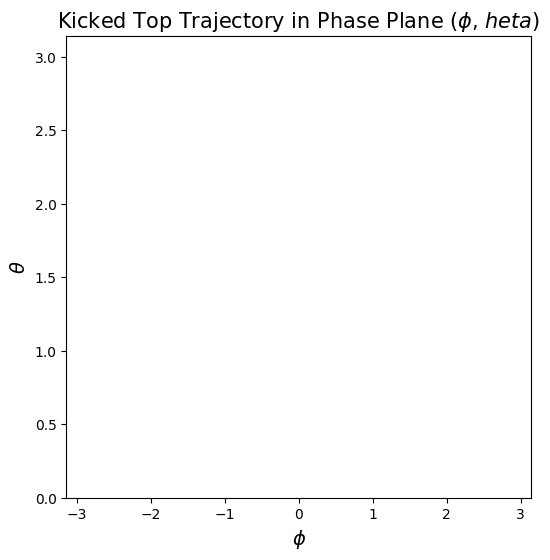

In [9]:
# ---------- Parameters ----------
# scar_p3_B
theta0 = 0.48625606778264796
phi0 = -0.59829879850284

# scar_p3_G
theta0 = 1.1743491586675172
phi0 = -2.0027122747521653

# scar_p3_M
theta0 = 0.7854563206156052
phi0 = -1.5707963267728335

# scar_p3_P
theta0 = 0.785456320641713
phi0 = -0.015251882214227928

# AA
theta0 = 0.5*np.pi
phi0 = -0.5*np.pi

# BB
theta0 = 0.785
phi0 = -2.2388

# CC
theta0 = 0.5*np.pi
phi0 = 0

# DD
theta0 = 1.174
phi0 = -1.146

# EE
theta0 = 0
phi0 = 0

# FF
theta0 = 2.356
phi0 = -0.817

# GG
theta0 = 1.967
phi0 = -1.995

# HH
theta0 = 0.86
phi0 = -2.45

# scar_p4_O
theta0 = 0.9084877169872193
phi0 = -2.4651597532491523

# scar_tr_B
theta0 = 0.48625606778264796
phi0 = -0.59829879850284 + np.pi

# scar_tr_G
theta0 = 1.1743491586675172
phi0 = -2.0027122747521653 + np.pi

# scar_tr_M
theta0 = 0.7854563206156052
phi0 = -1.5707963267728335 + np.pi

# scar_tr_P
theta0 = 0.785456320641713
phi0 = -0.015251882214227928 + np.pi

# tr_BB
theta0 = 0.785
phi0 = -2.2388 + np.pi



x0 = sph_to_cart(theta0, phi0)

kappa = 2.2
alpha = np.pi / 2
p_order = 2
N = 100

trajectory = generate_trajectory(x0, kappa, alpha, p_order, N)
x_vals = trajectory[:, 0]
y_vals = trajectory[:, 1]
z_vals = trajectory[:, 2]

# ========== Convert to (phi, theta) ==========
phi_vals = np.arctan2(y_vals, x_vals)        # ∈ [−π, π]
theta_vals = np.arccos(z_vals)               # ∈ [0, π]

# ========== PLOT ==========
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([0, np.pi])
ax.set_xlabel(r"$\phi$", fontsize=14)
ax.set_ylabel(r"$\theta$", fontsize=14)
ax.set_title("Kicked Top Trajectory in Phase Plane ($\phi$, $\theta$)", fontsize=15)

point, = ax.plot([], [], 'ro', markersize=5)
trail, = ax.plot([], [], 'r-', lw=1)

def init():
    point.set_data([], [])
    trail.set_data([], [])
    return point, trail

def update(frame):
    point.set_data([phi_vals[frame]], [theta_vals[frame]])
    trail.set_data(phi_vals[:frame+1], theta_vals[:frame+1])
    return point, trail

ani = FuncAnimation(
    fig, update, frames=N+1, init_func=init,
    interval=50, repeat=False
)

# ========== SAVE TO MP4 ==========
writer = FFMpegWriter(fps=5, metadata=dict(artist='You'), bitrate=1800)
ani.save("kicked_top_theta_phi.mp4", writer=writer)
print("Saved as 'kicked_top_theta_phi.mp4'")